# Pupillometry disco ball acquisition pipeline

Pipeline for acquiriing pupillometry data with the disco ball.

The data is saved locally to the desktop. Please back up data to the cluster afterwards. 

Run each section below in order:
1. Setup 
2. Calibration
3. Data Acquisition
4. Data Processing



Notes: 
- I have kept the variable names "d" and "p" from the original code. As I understand it, "d" refers to the access to SpectraTuneLab and is used to control disco ball. "p" is used for the instance of recording through PupilLabs and is used to control eye capture.
- Need to incorporate figure saving. 

## Setup environment, libraries and subject directory

### Import libraries

In [1]:
import os
from datetime import datetime
import pandas as pd
from pipeline_utils import create_subject_folder
from eyebrain_protocol import run_eyebrain_stimulus_administration
from data_processing import smooth_eyebrain_data, get_stamps, create_multi_index_df, compute_and_plot_PIPR, plr
import seaborn as sns

In [2]:
from calibrate import calibrate_pupilcapture, calibrate_spectral_sensitivity
from pyplr import stlab
from pyplr.pupil import PupilCore
from pyplr import graphing
from pyplr import preproc
import matplotlib.pyplot as plt
import numpy as np
from pyplr import utils
from copy import deepcopy

In [3]:
# Set up stlab (light engine). Make sure you have turned on the disco ball before running this!

d = stlab.SpectraTuneLab(password='2294b16eea08a15a')
d.turn_off()

LIGHT HUB login success
User authenticated as: admin
The following addresses are defined: [1, 1004, 1023]
Call get_luminaires() / get_device_info() for more info


<Response [200]>

### Input subject ID and create output folder

In [4]:
# define subject ID
subject_id = input("please enter subject_id:")

please enter subject_id: lk-test


In [5]:
# create subject directory on the local machine desktop
subject_folder_path = create_subject_folder(subject_id)

Do you want to proceed anyway? (y/n):  y


Proceeding with creating folder...
Folder 'sub-lk-test_ses-01_dat-20250722' created successfully at: C:\Users\reub0220\Desktop\sub-lk-test_ses-01_dat-20250722


## Run calibration

This section calibrates the eye capture and ensures spectral sensitivity. 

### Calibrate eye capture

Ensure the subject is wearing glasses and PupilCapture is started and both eyes in view. 

Fit model to ensure pupil circles are dark blue. 

Ask subject to roll eyes, then fix eyes and roll head.

If you are not happy with the model fit, re-run this cell. 

> Refit the 3d model? [y/n]:  y


> Unfreezing 3d model for eye 0
> Unfreezing 3d model for eye 1
> Ask the participant to roll their eyes


> Press "Enter" when ready to freeze the model:  


> Freezing 3d model for eye 0
> Freezing 3d model for eye 1
> Grabbing 5 seconds of pupil.1.3d
> PupilGrabber done grabbing 5 seconds of pupil.1.3d


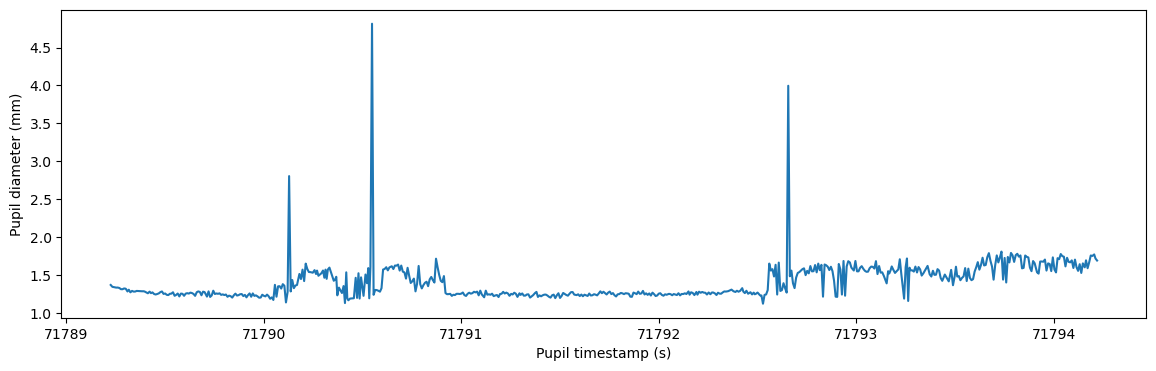

In [7]:
# creates object p to access the PupilCore with calibrated settings
p = calibrate_pupilcapture()

### Calibrate colours and spectral sensitivity

Calibrate spectral sensitivity and find optimal blue and red light

(0,)
(1,)
(2,)
(3,)
(4,)
(5,)
(6,)
(7,)
(8,)
(9,)


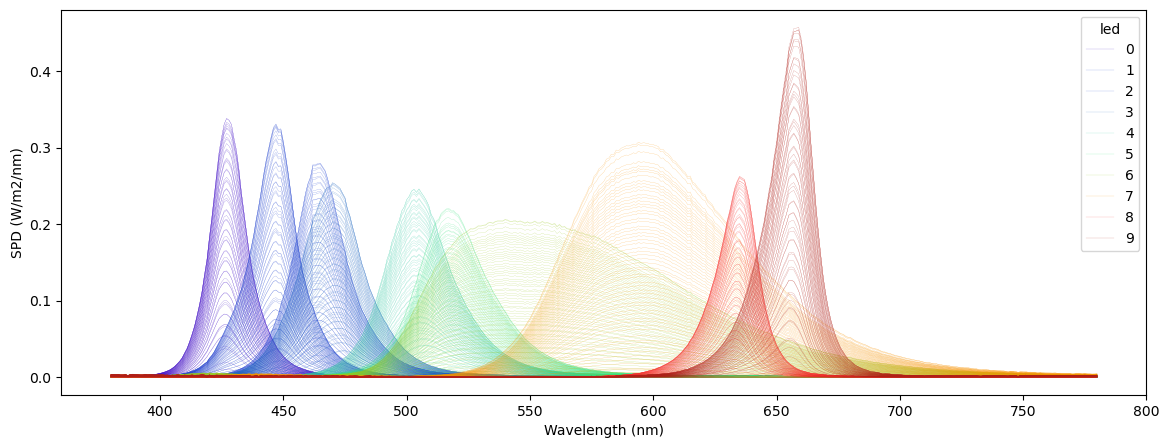

In [8]:
blue_intensity, red_intensity = calibrate_spectral_sensitivity(d)

## Data Acquisition

 Note
        ----
        Requires a suitable geometry and for the World Camera to be pointed at
        the light source. Also requires the following settings in Pupil
        Capture:

        * Auto Exposure mode - Manual Exposure (eye and world)
        * Frame publisher format - BGR

### Stimulus administration
Make sure participant is comfortable and set up. 
It starts with a prompt to input subject ID - this is to confirm that everyone is ready for acquisition to begin. 

- Once the subject ID is entered, it will take about 2 seconds before 1st (blue) flash. 
- Stimulus then takes 1 second, then there is about 90.5 seconds to next flash.
- In total, there are 6 flashes: starting with blue then alternating with red. 
- This also tracks data from both pupils, so you can see both pupils on the laptop and ask participant to adjust as needed. 
- Output from this cell should include timestamps from the flash (exactly 6). 
- Once 6th flash + 90s is done, there will be about 20s of "Waiting for futures..." being printed, before it is done.
- It will then output: PupilGrabber done grabbing 570 seconds of pupil.0.3d, PupilGrabber done grabbing 570 seconds of pupil.1.3d.
- Finally, there will be a plot of each pupil against timestamps. 

In [9]:
# ask for subject ID to start the protocol
subject_id_check = input("please enter subject_id:")

if subject_id_check == subject_id:
    print(f"Subject ID {subject_id} is correct. Proceeding with the protocol.")
    data_eye0, data_eye1, timestamp = run_eyebrain_stimulus_administration(d, p, blue_intensity, red_intensity)
    # save the data to CSV files - MAKE SURE TIMESTAMP IS GOOD
    result_file_name = f'pipr-90s-binoc-sub-{subject_id}_ses-01_tim-{timestamp}'
    data_eye0.to_csv(subject_folder_path + '/' + result_file_name + '-eye0.csv')
    data_eye1.to_csv(subject_folder_path + '/' + result_file_name + '-eye1.csv')
else:
    print(f"Subject ID {subject_id_check} does not match {subject_id}. Please try again to start protocol.")
    exit()

please enter subject_id: lk-test


Subject ID lk-test is correct. Proceeding with the protocol.
> Grabbing 570 seconds of pupil.1.3d
> Grabbing 570 seconds of pupil.0.3d
Trial 1: Administering BLUE stimulus (LED 3)
> Waiting for a light to stamp...
Trial 1 complete.
Trial 2/6: Warning - stimulus in 10 seconds
Trial 2: Administering RED stimulus (LED 9)
> Waiting for a light to stamp...
Trial 2 complete.
Trial 3/6: Warning - stimulus in 10 seconds
Trial 3: Administering BLUE stimulus (LED 3)
> Waiting for a light to stamp...
Trial 3 complete.
Trial 4/6: Warning - stimulus in 10 seconds
Trial 4: Administering RED stimulus (LED 9)
> Waiting for a light to stamp...
Trial 4 complete.
Trial 5/6: Warning - stimulus in 10 seconds
Trial 5: Administering BLUE stimulus (LED 3)
> Waiting for a light to stamp...
Trial 5 complete.
Trial 6/6: Warning - stimulus in 10 seconds
Trial 6: Administering RED stimulus (LED 9)
> Waiting for a light to stamp...
Trial 6 complete.
Waiting for futures...
Waiting for futures...
Waiting for futures.

ValueError: cannot reshape array of size 78416 into shape (720,1280,3)

## Data Processing

In [ ]:
# display data from pandas table
data_eye0.head()

In [ ]:
data_eye1.head()

### Plot data

In [10]:
timestamps_eye0 = data_eye0['timestamp']
timestamps_eye1 = data_eye1['timestamp']
diam_3d_eye0 = data_eye0['diameter_3d']
diam_3d_eye1 = data_eye1['diameter_3d']

NameError: name 'data_eye0' is not defined

In [ ]:
plt.figure()
plt.plot(timestamps_eye0, diam_3d_eye0, 'r') # this should be the smoothed out data - if not, check
plt.plot(timestamps_eye1, diam_3d_eye1, 'b') # this should be the smoothed out data - if not, check
plt.show()

### Apply butterworth filter

In [ ]:
# Filtering and processing 

filtered_data_eye0 = smooth_eyebrain_data(data_eye0)
filtered_data_eye1 = smooth_eyebrain_data(data_eye1)

# save processed data to CSV files
filtered_data_eye0.to_csv(subject_folder_path + '/' + result_file_name + '-butterworth-eye0.csv') 
filtered_data_eye1.to_csv(subject_folder_path + '/' + result_file_name + '-butterworth-eye1.csv') 

### Create multi-index data

Disclaimer: I have restructured this code into functions but have little understanding of why it's written this way

In [ ]:
# get relevant timestamps for the eyebrain protocol
stamps_eye0 = get_stamps(timestamps_eye0)
stamps_eye1 = get_stamps(timestamps_eye1)

# only want some of the columns?
partial_data_eye0 = data_eye0[['timestamp', 'confidence','id','diameter','diameter_3d']]
partial_data_eye1 = data_eye1[['timestamp', 'confidence','id','diameter','diameter_3d']]

# create multi-index data
multi_index_df_eye0 = create_multi_index_df(partial_data_eye0, stamps_eye0)
multi_index_df_eye1 = create_multi_index_df(partial_data_eye1, stamps_eye1)

In [ ]:
# run butterworth filter on the multi-index data
filtered_multi_index_df_eye0 = smooth_eyebrain_data(multi_index_df_eye0)
filtered_multi_index_df_eye1 = smooth_eyebrain_data(multi_index_df_eye1)

In [ ]:
# check dataframes
filtered_multi_index_df_eye0.head()

In [ ]:
filtered_multi_index_df_eye1.head()

In [ ]:
# we want to plot this as well it seems
plt.figure(figsize=(10, 5))
filtered_multi_index_df_eye0["diameter_3d"].plot()
plt.show()

In [ ]:
# we want to plot this as well it seems
plt.figure(figsize=(10, 5))
filtered_multi_index_df_eye1["diameter_3d"].plot()
plt.show()

### Plot and compute PIPR

In [ ]:
# eye0
avgs_eye0, pipr_fig_eye0 = compute_and_plot_PIPR(filtered_multi_index_df_eye0, 'eye0')

In [ ]:
# eye1
avgs_eye1, pipr_fig_eye1 = compute_and_plot_PIPR(filtered_multi_index_df_eye0, 'eye1')

### plr?

In [ ]:
plr_params_eye0, plr_fig_eye0 = plr(filtered_multi_index_df_eye0)

In [ ]:
plr_params_eye1, plr_fig_eye1 = plr(filtered_multi_index_df_eye1)

### Save data

In [ ]:
multi_index_df_eye0.to_csv(subject_folder_path + '/' + result_file_name + '-processed-eye0.csv') 
multi_index_df_eye1.to_csv(subject_folder_path + '/' + result_file_name + '-processed-eye1.csv') 

avgs_eye0.to_csv(subject_folder_path + '/' + result_file_name + '-average-pipr-eye0.csv')
avgs_eye1.to_csv(subject_folder_path + '/' + result_file_name + '-average-pipr-eye1.csv')

In [ ]:
# save figures
if not os.path.exists(subject_folder_path + 'figures'):
    os.makedirs(subject_folder_path + 'figures')

# Save the figures in the folder
#fig.savefig(path_base + 'figures/' + subj_base + '-eye1.png')

## IMPORTANT: Run the next cell to clear cell output to avoid sensitive information being commited to Git. 

In [1]:
from IPython.display import clear_output

for i in range(10):
    clear_output(wait=True)
    print(i, flush=True)

9
